# Libraries and functions

In [3]:
import numpy as np
from numpy.polynomial.hermite import hermgauss
from scipy.optimize import least_squares
from scipy.special import ndtr


# =========================
# Basic Gaussian functions
# =========================

SQRT2 = np.sqrt(2.0)
SQRT2PI = np.sqrt(2.0 * np.pi)


def H(x):
    """
    H(x) = \int_x^\infty Dz = Phi(-x)
    """
    return ndtr(-x)


def phi(x):
    """
    Standard normal pdf.
    """
    return np.exp(-0.5 * x * x) / SQRT2PI


# =====================================
# Logistic potential and local minimizer
# =====================================

def V_lambda(delta, lam):
    """
    Logistic potential used in the teacher paper:
        V_lambda(Delta) = -Delta + (1/lambda) log(2 cosh(lambda Delta))
    Numerically stable via logaddexp.
    """
    z = lam * delta
    return -delta + np.logaddexp(z, -z) / lam


def solve_delta0(t, x, lam, max_iter=80, tol=1e-12):
    """
    Solve for Delta0(t, x), i.e. the unique minimizer of

        V_lambda(Delta) + (Delta - t)^2 / (2x)

    For the logistic loss, Delta0 satisfies
        Delta - t + x * (tanh(lambda Delta) - 1) = 0.

    Robust trick:
    since tanh(.) - 1 is in [-2, 0], the solution always lies in [t, t + 2x].
    We therefore use a safeguarded Newton method with a guaranteed bracket.
    """
    t = np.asarray(t, dtype=float)

    lo = t.copy()
    hi = t + 2.0 * x

    # Good initial guess inside the bracket
    delta = np.clip(t + x, lo, hi)

    for _ in range(max_iter):
        z = np.clip(lam * delta, -40.0, 40.0)
        tanh_z = np.tanh(z)
        sech2_z = 1.0 / np.cosh(z) ** 2

        f = delta - t + x * (tanh_z - 1.0)
        if np.max(np.abs(f)) < tol:
            break

        fp = 1.0 + x * lam * sech2_z
        newton = delta - f / fp

        # update the bracket
        left = (f < 0.0)
        lo = np.where(left, delta, lo)
        hi = np.where(left, hi, delta)

        # if Newton jumps outside, fall back to bisection
        bad = (~np.isfinite(newton)) | (newton <= lo) | (newton >= hi)
        delta = np.where(bad, 0.5 * (lo + hi), newton)

    return delta


# ==========================
# Gauss-Hermite integration
# ==========================

class GaussianQuadrature:
    """
    Precompute nodes/weights for integrals of the form
        \int Dt f(t),   Dt = exp(-t^2/2) dt / sqrt(2pi).
    """
    def __init__(self, n_gh=200):
        nodes, weights = hermgauss(n_gh)
        self.t = np.sqrt(2.0) * nodes
        self.w = weights / np.sqrt(np.pi)


# =========================================
# Teacher-biased field and saddle equations
# =========================================

def teacher_field_factor(t, R):
    """
    Factor multiplying Dt in the teacher case:
        p_R(t) / Dt = 2 H( - R t / sqrt(1-R^2) )

    So p_R(t) = Dt * teacher_field_factor(t, R).
    """
    s = np.sqrt(np.maximum(1e-300, 1.0 - R * R))
    return 2.0 * H(-(R / s) * t)


def energy_density_terms(x, R, lam, alpha, quad):
    """
    Return all pieces needed for the saddle equations.
    """
    t = quad.t
    delta0 = solve_delta0(t, x, lam)
    teacher_factor = teacher_field_factor(t, R)

    local_energy = V_lambda(delta0, lam) + (delta0 - t) ** 2 / (2.0 * x)
    return t, delta0, teacher_factor, local_energy


def B_objective(x, R, lam, alpha, quad):
    """
    The bracket inside the extremization:
        B(x,R) = (1-R^2)/(2x) - 2 alpha \int Dt H(...) [ ... ]
               = (1-R^2)/(2x) - alpha \int Dt [2H(...)] [ ... ].
    """
    t, delta0, teacher_factor, local_energy = energy_density_terms(
        x, R, lam, alpha, quad
    )
    return (1.0 - R * R) / (2.0 * x) - alpha * np.sum(
        quad.w * teacher_factor * local_energy
    )


def x_equation_residual(x, R, lam, alpha, quad):
    """
    Exact x saddle equation from the envelope theorem:
        1 - R^2 = alpha \int Dt [2H(...)] (t - Delta0)^2.
    """
    t, delta0, teacher_factor, _ = energy_density_terms(x, R, lam, alpha, quad)
    rhs = alpha * np.sum(quad.w * teacher_factor * (t - delta0) ** 2)
    return rhs - (1.0 - R * R)


def dB_dR_exact(x, R, lam, alpha, quad):
    """
    Exact derivative of B wrt R.
    Using
        d/dR [ 2H(-R t / sqrt(1-R^2)) ]
        = 2 phi( R t / sqrt(1-R^2) ) * t / (1-R^2)^(3/2).
    """
    t, delta0, _, local_energy = energy_density_terms(x, R, lam, alpha, quad)

    s2 = np.maximum(1e-300, 1.0 - R * R)
    s = np.sqrt(s2)
    z = (R / s) * t

    d_teacher_factor_dR = 2.0 * phi(z) * t / (s ** 3)

    return -R / x - alpha * np.sum(quad.w * d_teacher_factor_dR * local_energy)


def saddle_residuals(params, lam, alpha, quad):
    """
    Work in transformed variables:
        x = exp(logx) > 0
        R = tanh(u) in (-1, 1)
    """
    logx, u = params
    x = np.exp(logx)
    R = np.tanh(u)

    return np.array([
        x_equation_residual(x, R, lam, alpha, quad),
        dB_dR_exact(x, R, lam, alpha, quad),
    ])


def solve_teacher_saddle(alpha, lam, n_gh=200):
    """
    Solve the teacher saddle equations and return x, R, epsilon_gen.

    A small multi-start makes the solver much more robust.
    """
    quad = GaussianQuadrature(n_gh=n_gh)

    initials = [
        np.array([0.0, 0.0]),
        np.array([0.0, 0.5]),
        np.array([-1.0, 0.5]),
        np.array([0.5, 1.0]),
        np.array([-2.0, 2.0]),
    ]

    best = None
    for p0 in initials:
        sol = least_squares(
            lambda p: saddle_residuals(p, lam, alpha, quad),
            x0=p0,
            bounds=([-12.0, -8.0], [12.0, 8.0]),
            xtol=1e-12,
            ftol=1e-12,
            gtol=1e-12,
            max_nfev=500,
        )
        score = np.linalg.norm(sol.fun)
        if best is None or score < best["residual_norm"]:
            x = float(np.exp(sol.x[0]))
            R = float(np.tanh(sol.x[1]))
            best = {
                "x": x,
                "R": R,
                "epsilon_gen": float(np.arccos(np.clip(R, -1.0, 1.0)) / np.pi),
                "residual_norm": float(score),
                "success": bool(sol.success),
                "solver": sol,
                "quad": quad,
            }

    return best


# ============================================
# Closed-form stability pdf once x,R are known
# ============================================

def stability_pdf_on_grid(delta_grid, x, R, lam):
    """
    Closed-form teacher stability density:

        P(Delta) = 2 phi(t(Delta))
                   H( - R t(Delta) / sqrt(1-R^2) )
                   * dt/dDelta

    where
        t(Delta) = Delta + x (tanh(lambda Delta) - 1)
        dt/dDelta = 1 + x lambda sech^2(lambda Delta).
    """
    delta = np.asarray(delta_grid, dtype=float)

    z = np.clip(lam * delta, -40.0, 40.0)
    tanh_z = np.tanh(z)
    sech2_z = 1.0 / np.cosh(z) ** 2

    t_of_delta = delta + x * (tanh_z - 1.0)
    jac = 1.0 + x * lam * sech2_z

    s = np.sqrt(np.maximum(1e-300, 1.0 - R * R))
    pdf = 2.0 * phi(t_of_delta) * H(-(R / s) * t_of_delta) * jac

    return pdf


def auto_delta_grid(x, lam, n_points=2000, tmax=8.0):
    """
    Build a safe Delta grid.
    Since Delta is in [t, t+2x] pointwise and almost all Gaussian mass is in [-8, 8],
    this range is usually ample.
    """
    dmin = -2
    dmax = 7
    return np.linspace(dmin, dmax, n_points)


def solve_teacher_stability_distribution(alpha, lam, n_gh=200, n_delta=2000):
    """
    Main user function.

    Returns a dictionary with:
      - x, R, epsilon_gen
      - delta_grid
      - pdf
      - residual_norm
      - success
    """
    if lam <= 0:
        raise ValueError("lam must be > 0. For the Hebbian limit, use a very small positive lam.")

    saddle = solve_teacher_saddle(alpha=alpha, lam=lam, n_gh=n_gh)
    x = saddle["x"]
    R = saddle["R"]

    delta_grid = auto_delta_grid(x=x, lam=lam, n_points=n_delta)
    pdf = stability_pdf_on_grid(delta_grid, x=x, R=R, lam=lam)

    # small numerical renormalization
    Z = np.trapz(pdf, delta_grid)
    if Z > 0:
        pdf = pdf / Z

    out = {
        "alpha": float(alpha),
        "lambda": float(lam),
        "x": x,
        "R": R,
        "epsilon_gen": saddle["epsilon_gen"],
        "delta_grid": delta_grid,
        "pdf": pdf,
        "residual_norm": saddle["residual_norm"],
        "success": saddle["success"],
    }
    return out



In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl


def plot_teacher_stability_distributions(
    alpha,
    lambdas,
    n_gh=200,
    n_delta=2000,
    ax=None,
    figsize=(7, 5),
    lw=2.0,
    line_alpha=0.95,
    cmap="magma",
    add_colorbar=True,
    sort_lambdas=True,
    label_curves=False,
):
    """
    Compute and plot teacher stability distributions for an array of lambdas.

    Parameters
    ----------
    alpha : float
        Load parameter alpha = P / N.

    lambdas : array-like
        1D array of positive lambda values.

    n_gh : int
        Number of Gauss-Hermite nodes.

    n_delta : int
        Number of Delta grid points for the pdf.

    ax : matplotlib axis or None
        Axis where to plot. If None, creates a new figure.

    figsize : tuple
        Figure size if ax is None.

    lw : float
        Line width.

    line_alpha : float
        Transparency of the lines.

    cmap : str
        Matplotlib colormap name.

    add_colorbar : bool
        Whether to add the colorbar.

    sort_lambdas : bool
        If True, plot curves in increasing lambda.

    label_curves : bool
        If True, add a legend label for each curve.

    Returns
    -------
    ax : matplotlib axis
    results : list of dict
        One result dict per lambda, each containing x, R, epsilon_gen,
        delta_grid, pdf, etc.
    """
    lambdas = np.asarray(lambdas, dtype=float)

    if lambdas.ndim != 1 or lambdas.size == 0:
        raise ValueError("lambdas must be a non-empty 1D array.")
    if np.any(lambdas <= 0):
        raise ValueError("All lambda values must be strictly positive.")

    if sort_lambdas:
        order = np.argsort(lambdas)
        lambdas = lambdas[order]

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    cmap_obj = plt.get_cmap(cmap)

    if lambdas.size == 1:
        # trivial normalization if only one lambda is given
        norm = mpl.colors.LogNorm(vmin=lambdas[0], vmax=lambdas[0] * 1.01)
    else:
        norm = mpl.colors.LogNorm(vmin=np.min(lambdas), vmax=np.max(lambdas))

    results = []

    for lam in lambdas:
        res = solve_teacher_stability_distribution(
            alpha=alpha,
            lam=float(lam),
            n_gh=n_gh,
            n_delta=n_delta,
        )
        results.append(res)

        color = cmap_obj(norm(lam))
        label = fr"$\lambda={lam:g}$" if label_curves else None

        ax.plot(
            res["delta_grid"],
            res["pdf"],
            color=color,
            lw=lw,
            alpha=line_alpha,
            label=label,
        )

    ax.set_xlabel(r"stability $\Delta$")
    ax.set_ylabel(r"$P_{\alpha,\lambda}^{\mathrm{teach}}(\Delta)$")
    ax.set_title(fr"Teacher stability distributions, $\alpha={alpha}$")
    ax.grid(True, alpha=0.3)

    if add_colorbar:
        sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap_obj)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax)
        cbar.set_label(r"$\lambda$")

    if label_curves:
        ax.legend()

    return ax, results

# Tests

/tmp/ipykernel_23572/4293545468.py:296: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Z = np.trapz(pdf, delta_grid)


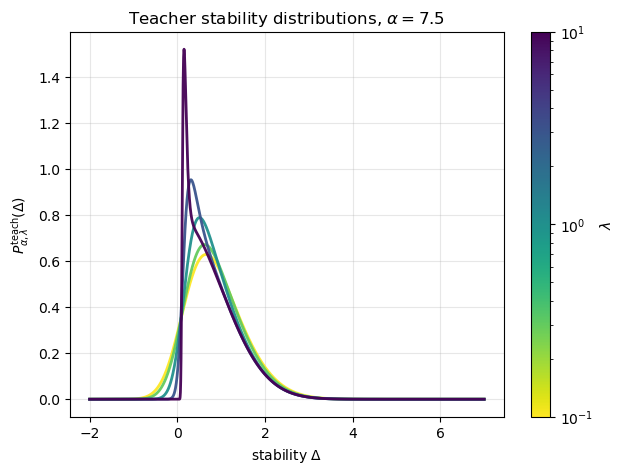

In [5]:
lambdas = np.array([0.1, 0.3, 1.0, 3.0, 10.0])

ax, results = plot_teacher_stability_distributions(
    alpha=7.5,
    lambdas=lambdas,
    n_gh=200,
    n_delta=2500,
    cmap="viridis_r",
    add_colorbar=True,
    label_curves=False,
)

plt.show()

/tmp/ipykernel_22608/4293545468.py:296: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Z = np.trapz(pdf, delta_grid)


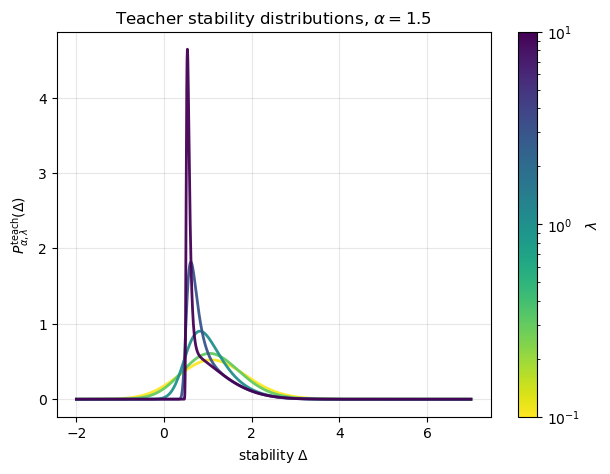

In [18]:
lambdas = np.array([0.1, 0.3, 1.0, 3.0, 10.0])

ax, results = plot_teacher_stability_distributions(
    alpha=1.5,
    lambdas=lambdas,
    n_gh=200,
    n_delta=2500,
    cmap="viridis_r",
    add_colorbar=True,
    label_curves=False,
)

plt.show()

/tmp/ipykernel_22608/4293545468.py:296: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Z = np.trapz(pdf, delta_grid)


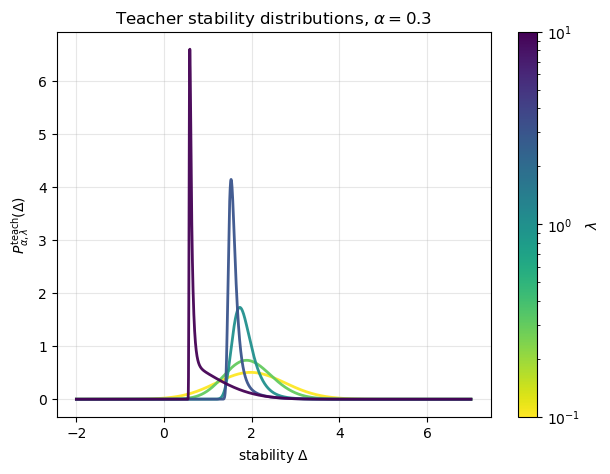

In [17]:
lambdas = np.array([0.1, 0.3, 1.0, 3.0, 10.0])

ax, results = plot_teacher_stability_distributions(
    alpha=0.3,
    lambdas=lambdas,
    n_gh=200,
    n_delta=2500,
    cmap="viridis_r",
    add_colorbar=True,
    label_curves=False,
)

plt.show()